<a href="https://colab.research.google.com/github/Nikhilsankhyan0/Agrisheild-AI/blob/main/regression_model_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
x_train = pd.read_csv(
    "/content/drive/MyDrive/X_train_encoded.csv"
)

x_val = pd.read_csv(
    "/content/drive/MyDrive/X_val_encoded.csv"
)

x_test = pd.read_csv(
    "/content/drive/MyDrive/X_test_encoded.csv"
)

y_train_reg = pd.read_csv(
    "/content/drive/MyDrive/y_train_reg.csv"
).squeeze()

y_val_reg = pd.read_csv(
    "/content/drive/MyDrive/y_val_reg.csv"
).squeeze()

y_test_reg = pd.read_csv(
    "/content/drive/MyDrive/y_test_reg.csv"
).squeeze()

In [4]:
print(x_train.shape )
print(x_val.shape)
print(x_test.shape)

(14000, 259)
(3000, 259)
(3000, 259)


In [5]:
print(y_train_reg.shape)
print(y_val_reg.shape)
print(y_test_reg.shape)

(14000,)
(3000,)
(3000,)


In [6]:
print("X_train :", x_train.isnull().sum().sum())
print("X_val   :", x_val.isnull().sum().sum())
print("X_test  :", x_test.isnull().sum().sum())

print("y_train :", y_train_reg.isnull().sum())
print("y_val   :", y_val_reg.isnull().sum())
print("y_test  :", y_test_reg.isnull().sum())

X_train : 0
X_val   : 0
X_test  : 0
y_train : 0
y_val   : 0
y_test  : 0


target is numeric

In [7]:
y_train_reg = pd.to_numeric(y_train_reg)
y_val_reg = pd.to_numeric(y_val_reg)
y_test_reg = pd.to_numeric(y_test_reg)

print(y_train_reg.dtype)
print(y_val_reg.dtype)
print(y_test_reg.dtype)

float64
float64
float64


Create evaluation function

In [8]:
def evaluate_model(model, x_train, y_train, x_val, y_val):

    model.fit(x_train, y_train)

    y_pred = model.predict(x_val)

    mae = mean_absolute_error(
        y_val,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            y_pred
        )
    )

    r2 = r2_score(
        y_val,
        y_pred
    )

    return mae, rmse, r2

In [9]:
linear_model = LinearRegression()

mae_linear, rmse_linear, r2_linear = evaluate_model(
    linear_model,
    x_train,
    y_train_reg,
    x_val,
    y_val_reg
)

print("===== LINEAR REGRESSION =====")
print(f"MAE  : {mae_linear:.4f}")
print(f"RMSE : {rmse_linear:.4f}")
print(f"R²   : {r2_linear:.4f}")

===== LINEAR REGRESSION =====
MAE  : 4.1796
RMSE : 5.3001
R²   : 0.8239


In [10]:
decision_tree = DecisionTreeRegressor(
    random_state=42
)

mae_tree, rmse_tree, r2_tree = evaluate_model(
    decision_tree,
    x_train,
    y_train_reg,
    x_val,
    y_val_reg
)

print("===== DECISION TREE =====")
print(f"MAE  : {mae_tree:.4f}")
print(f"RMSE : {rmse_tree:.4f}")
print(f"R²   : {r2_tree:.4f}")

===== DECISION TREE =====
MAE  : 6.5080
RMSE : 8.2938
R²   : 0.5689


In [11]:
random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

mae_rf, rmse_rf, r2_rf = evaluate_model(
    random_forest,
    x_train,
    y_train_reg,
    x_val,
    y_val_reg
)

print("===== RANDOM FOREST =====")
print(f"MAE  : {mae_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

===== RANDOM FOREST =====
MAE  : 4.4974
RMSE : 5.6630
R²   : 0.7990


In [12]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

mae_gb, rmse_gb, r2_gb = evaluate_model(
    gradient_boosting,
    x_train,
    y_train_reg,
    x_val,
    y_val_reg
)

print("===== GRADIENT BOOSTING =====")
print(f"MAE  : {mae_gb:.4f}")
print(f"RMSE : {rmse_gb:.4f}")
print(f"R²   : {r2_gb:.4f}")

===== GRADIENT BOOSTING =====
MAE  : 4.3118
RMSE : 5.4604
R²   : 0.8131


In [13]:
results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        mae_linear,
        mae_tree,
        mae_rf,
        mae_gb
    ],

    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_rf,
        rmse_gb
    ],

    "R2": [
        r2_linear,
        r2_tree,
        r2_rf,
        r2_gb
    ]
})

results = results.sort_values(
    by="R2",
    ascending=False
)

print(results)

               Model       MAE      RMSE        R2
0  Linear Regression  4.179608  5.300103  0.823949
3  Gradient Boosting  4.311763  5.460384  0.813140
2      Random Forest  4.497384  5.662976  0.799017
1      Decision Tree  6.507967  8.293789  0.568903


trying GB hypermeter tuning


In [14]:
from sklearn.ensemble import GradientBoostingRegressor

gb_models = {

    "GB_100": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "GB_200": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "GB_300": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "GB_200_depth2": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    ),

    "GB_200_depth4": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
}

In [15]:
gb_results = []

for name, model in gb_models.items():

    model.fit(
        x_train,
        y_train_reg
    )

    y_pred = model.predict(
        x_val
    )

    mae = mean_absolute_error(
        y_val_reg,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val_reg,
            y_pred
        )
    )

    r2 = r2_score(
        y_val_reg,
        y_pred
    )

    gb_results.append([
        name,
        mae,
        rmse,
        r2
    ])


In [16]:
gb_results_df = pd.DataFrame(
    gb_results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

print(
    gb_results_df.sort_values(
        "R2",
        ascending=False
    )
)

           Model       MAE      RMSE        R2
4  GB_200_depth4  4.244165  5.367649  0.819433
2         GB_300  4.231616  5.368388  0.819384
1         GB_200  4.311763  5.460384  0.813140
3  GB_200_depth2  4.451640  5.622591  0.801874
0         GB_100  4.556909  5.740374  0.793486


test regularization on linear model

ridge regression l2

In [17]:
from sklearn.linear_model import Ridge


Test several alpha values

alpha controls the strength of regularization.

Small alpha → behaves more like Linear Regression

Large alpha → stronger penalty on large coefficients

In [18]:
ridge_models={
    "Ridge_0.01":Ridge(alpha=0.01),
    "Ridge_0.1":Ridge(alpha=0.1),
    "Ridge_1":Ridge(alpha=1),
    "Ridge_10":Ridge(alpha=10),
    "Ridge_100":Ridge(alpha=100)

}

evaluate

In [19]:
ridge_result=[]
for name,model in ridge_models.items():
  mae,rmse,r2=evaluate_model(model,x_train,y_train_reg,x_val,y_val_reg)
  ridge_result.append([name,mae,rmse,r2])

/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.91048e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.78539e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.51956e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Create the comparison table

In [20]:
ridge_result_df=pd.DataFrame(ridge_result,columns=["Model","MAE","RMSE","R2"])
print(ridge_result_df.sort_values("R2",ascending=False))

        Model       MAE      RMSE        R2
3    Ridge_10  4.174204  5.290287  0.824601
2     Ridge_1  4.178246  5.297039  0.824153
1   Ridge_0.1  4.179333  5.299594  0.823983
0  Ridge_0.01  4.179577  5.300045  0.823953
4   Ridge_100  4.189602  5.313554  0.823054


In [21]:
best_ridge = Ridge(alpha=10)

best_ridge.fit(
    x_train,
    y_train_reg
)

y_pred_ridge = best_ridge.predict(x_val)

print("===== BEST RIDGE =====")
print(f"MAE  : {mean_absolute_error(y_val_reg, y_pred_ridge):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_val_reg, y_pred_ridge)):.4f}")
print(f"R²   : {r2_score(y_val_reg, y_pred_ridge):.4f}")

===== BEST RIDGE =====
MAE  : 4.1742
RMSE : 5.2903
R²   : 0.8246


now random forest tuning


In [22]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

# Random Forest models to compare

rf_models = {

    "RF_100": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "RF_depth10": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    "RF_depth20": RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),

    "RF_leaf2": RandomForestRegressor(
        n_estimators=100,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

In [23]:
rf_results = []

for name, model in rf_models.items():

    mae, rmse, r2 = evaluate_model(
        model,
        x_train,
        y_train_reg,
        x_val,
        y_val_reg
    )

    rf_results.append([
        name,
        mae,
        rmse,
        r2
    ])

In [24]:
rf_results_df = pd.DataFrame(
    rf_results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

rf_results_df = rf_results_df.sort_values(
    by="R2",
    ascending=False
)

print(rf_results_df)

        Model       MAE      RMSE        R2
0      RF_100  4.510542  5.680580  0.797766
3    RF_leaf2  4.512243  5.681542  0.797697
2  RF_depth20  4.509380  5.684768  0.797467
1  RF_depth10  4.575045  5.768576  0.791452


now XGBoost

In [25]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [26]:
from xgboost import XGBRegressor
xgb_baseline=XGBRegressor( n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1)

In [27]:
xgb_baseline.fit(x_train,y_train_reg)
y_pred_xgb=xgb_baseline.predict(x_val)

In [28]:
mae_xgb=mean_absolute_error(y_val_reg,y_pred_xgb)
rmse_xgb=np.sqrt(mean_squared_error(y_val_reg,y_pred))
r2_xgb=r2_score(y_val_reg,y_pred_xgb)
print("===== XGBOOST BASELINE =====")
print(f"MAE  : {mae_xgb:.4f}")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"R²   : {r2_xgb:.4f}")

===== XGBOOST BASELINE =====
MAE  : 4.3060
RMSE : 5.3676
R²   : 0.8142


In [29]:
xgb_models = {

    "XGB_100": XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "XGB_200": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "XGB_300": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

In [30]:
xgb_results = []

for name, model in xgb_models.items():

    mae, rmse, r2 = evaluate_model(
        model,
        x_train,
        y_train_reg,
        x_val,
        y_val_reg
    )

    xgb_results.append([
        name,
        mae,
        rmse,
        r2
    ])

In [31]:
xgb_results_df = pd.DataFrame(
    xgb_results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

print(
    xgb_results_df.sort_values(
        "R2",
        ascending=False
    )
)

     Model       MAE      RMSE        R2
2  XGB_300  4.230975  5.357343  0.820126
1  XGB_200  4.306019  5.444272  0.814241
0  XGB_100  4.550299  5.733995  0.793945


now changing the max depth

In [32]:
xgb_depth_models = {

    "XGB_depth2": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=2,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "XGB_depth3": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "XGB_depth4": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "XGB_depth5": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

In [33]:
xgb_depth_results = []

for name, model in xgb_depth_models.items():

    mae, rmse, r2 = evaluate_model(
        model,
        x_train,
        y_train_reg,
        x_val,
        y_val_reg
    )

    xgb_depth_results.append([
        name,
        mae,
        rmse,
        r2
    ])

In [34]:
xgb_depth_results_df = pd.DataFrame(
    xgb_depth_results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

print(
    xgb_depth_results_df.sort_values(
        "R2",
        ascending=False
    )
)

        Model       MAE      RMSE        R2
3  XGB_depth5  4.222654  5.326571  0.822186
2  XGB_depth4  4.214109  5.331949  0.821827
1  XGB_depth3  4.230975  5.357343  0.820126
0  XGB_depth2  4.301595  5.457618  0.813329


now tuning learning rate

In [35]:
xgb_lr_models = {

    "XGB_lr_0.03": XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "XGB_lr_0.05": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "XGB_lr_0.10": XGBRegressor(
        n_estimators=300,
        learning_rate=0.10,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

In [36]:
xgb_lr_models = {

    "XGB_lr_0.03": XGBRegressor(
        n_estimators=300,
        learning_rate=0.035,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "XGB_lr_0.05": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "XGB_lr_0.10": XGBRegressor(
        n_estimators=300,
        learning_rate=0.10,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

In [37]:
xgb_lr_results = []

for name, model in xgb_lr_models.items():

    mae, rmse, r2 = evaluate_model(
        model,
        x_train,
        y_train_reg,
        x_val,
        y_val_reg
    )

    xgb_lr_results.append([
        name,
        mae,
        rmse,
        r2
    ])

xgb_lr_results_df = pd.DataFrame(
    xgb_lr_results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

print(
    xgb_lr_results_df.sort_values(
        "R2",
        ascending=False
    )
)

         Model       MAE      RMSE        R2
1  XGB_lr_0.05  4.214109  5.331949  0.821827
0  XGB_lr_0.03  4.235518  5.360156  0.819937
2  XGB_lr_0.10  4.256009  5.377835  0.818747


now elastic net

In [38]:
from sklearn.linear_model import ElasticNet

elastic_models = {

    "ElasticNet_0.001": ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        max_iter=10000,
        random_state=42
    ),

    "ElasticNet_0.01": ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=10000,
        random_state=42
    ),

    "ElasticNet_0.1": ElasticNet(
        alpha=0.1,
        l1_ratio=0.5,
        max_iter=10000,
        random_state=42
    )
}

In [39]:
elastic_results = []

for name, model in elastic_models.items():

    mae, rmse, r2 = evaluate_model(
        model,
        x_train,
        y_train_reg,
        x_val,
        y_val_reg
    )

    elastic_results.append([
        name,
        mae,
        rmse,
        r2
    ])

elastic_results_df = pd.DataFrame(
    elastic_results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

print(
    elastic_results_df.sort_values(
        "R2",
        ascending=False
    )
)

              Model       MAE      RMSE        R2
1   ElasticNet_0.01  4.169682  5.284097  0.825011
0  ElasticNet_0.001  4.170707  5.284639  0.824975
2    ElasticNet_0.1  4.462546  5.668180  0.798648


final evaluation and model building

In [40]:
X_train_final = pd.concat(
    [x_train, x_val],
    axis=0
)

y_train_final = pd.concat(
    [y_train_reg, y_val_reg],
    axis=0
)

print("Final training X:", X_train_final.shape)
print("Final training y:", y_train_final.shape)

Final training X: (17000, 259)
Final training y: (17000,)


In [41]:
from sklearn.preprocessing import StandardScaler

final_scaler = StandardScaler()

X_train_final_scaled = final_scaler.fit_transform(
    X_train_final
)

X_test_scaled = final_scaler.transform(
    x_test
)

In [42]:
from sklearn.linear_model import ElasticNet

final_reg_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000,
    random_state=42
)

final_reg_model.fit(
    X_train_final_scaled,
    y_train_final
)

ElasticNet(alpha=0.01, max_iter=10000, random_state=42)

In [43]:
y_test_pred = final_reg_model.predict(
    X_test_scaled
)

In [44]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_test = mean_absolute_error(
    y_test_reg,
    y_test_pred
)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_test_pred
    )
)

r2_test = r2_score(
    y_test_reg,
    y_test_pred
)

In [45]:
print("===== FINAL REGRESSION MODEL =====")
print("Model : Elastic Net")
print("Alpha : 0.01")
print("L1 Ratio : 0.5")

print(f"MAE  : {mae_test:.4f}")
print(f"RMSE : {rmse_test:.4f}")
print(f"R²   : {r2_test:.4f}")

===== FINAL REGRESSION MODEL =====
Model : Elastic Net
Alpha : 0.01
L1 Ratio : 0.5
MAE  : 4.1372
RMSE : 5.2326
R²   : 0.8221


save the model

In [46]:
import joblib

In [47]:
joblib.dump(final_reg_model,'/content/drive/MyDrive/final_Risk_score_model.pkl')

['/content/drive/MyDrive/final_Risk_score_model.pkl']

In [48]:
joblib.dump(
    final_scaler,
    '/content/drive/MyDrive/regression_scaler.pkl'
)

print("Regression model and scaler saved successfully.")



Regression model and scaler saved successfully.


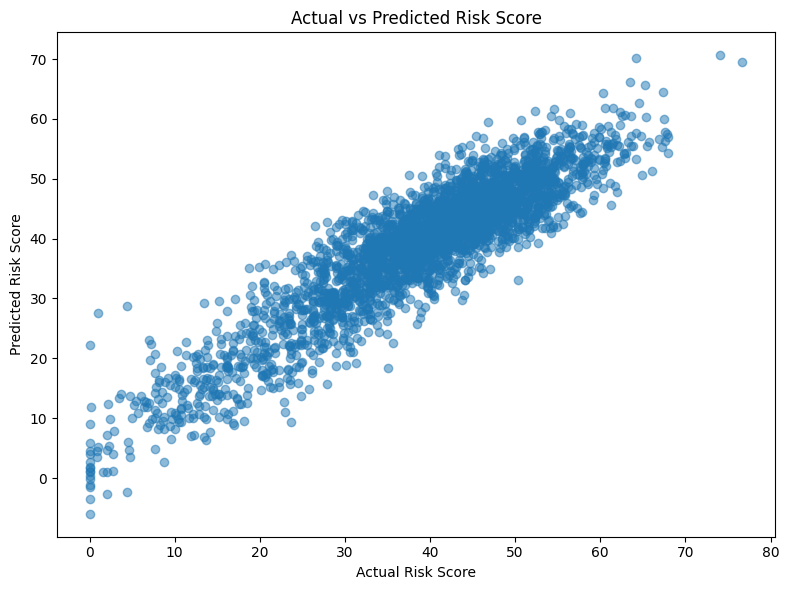

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_reg,
    y_test_pred,
    alpha=0.5
)

plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")
plt.title("Actual vs Predicted Risk Score")

plt.tight_layout()
plt.show()

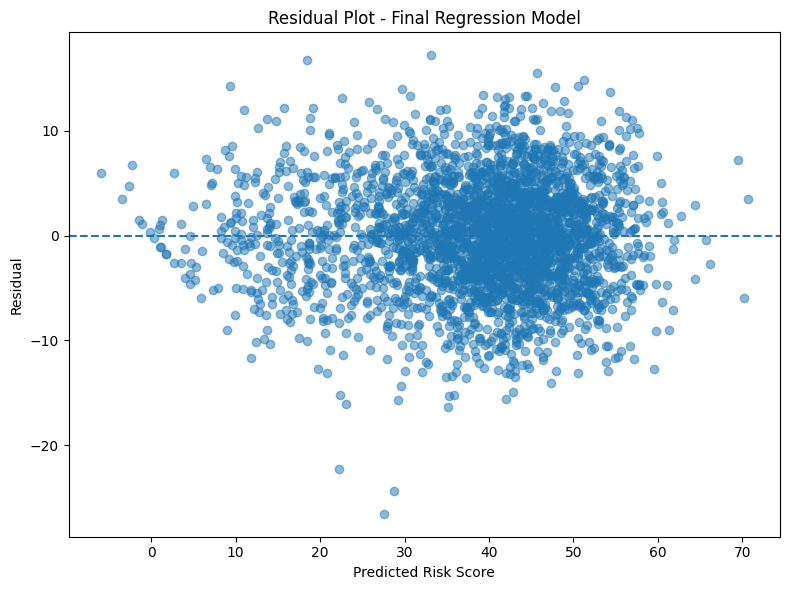

In [50]:
residuals = y_test_reg - y_test_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Risk Score")
plt.ylabel("Residual")
plt.title("Residual Plot - Final Regression Model")

plt.tight_layout()
plt.show()